# 스케줄링 GA 실행 결과

## 환경 설정

In [1]:
import os
import simpy
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# .env 파일의 환경 변수 로드
load_dotenv(override=True)

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
MACHINE_RULE = os.getenv('MACHINE_RULE', 'SPTSSU')
JOB_RULE = os.getenv('JOB_RULE', 'random')
PM_RULE = os.getenv('PM_RULE', 'THRESHOLD')
DOWN_TIME_UNIT = os.getenv('DOWN_TIME_UNIT', 'M')
TIME_UNIT = os.getenv('TIME_UNIT', 'M')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"MACHINE_RULE: {MACHINE_RULE}")
print(f"JOB_RULE: {JOB_RULE}")
print(f"PM_RULE: {PM_RULE}")
print(f"DOWN_TIME_UNIT: {DOWN_TIME_UNIT}")
print(f"TIME_UNIT: {TIME_UNIT}")

BASE_DATA_PATH: data/large_data
PM_HAZARD_THRESHOLD: 0.2
PM_ACTIVE: True
DOWN_ACTIVE: True
MACHINE_RULE: SPTSSU
JOB_RULE: GA
PM_RULE: THRESHOLD
DOWN_TIME_UNIT: H
TIME_UNIT: H


## 모듈 import

In [2]:
import time
import random
import simpy
import matplotlib.pyplot as plt
import pandas as pd
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler
from algorithms.genetic.encoder import encode
from algorithms.genetic.decoder import decode
from algorithms.genetic.ga import GA

## 데이터 로드

In [3]:
data = DataLoader(BASE_DATA_PATH).load_all_data()

print('데이터 개요')
print(f'Jobs:        {len(data["jobs"])}개')
print(f'Operations:  {len(data["operations"])}개')
print(f'Machines:    {len(data["machines"])}개')

데이터 개요
Jobs:        60개
Operations:  840개
Machines:    60개


## 인코딩

In [4]:
encoded = encode(data)

print(f'job_index_table 길이:       {len(encoded.job_index_table)}')
print(f'machine_index_table 길이:   {len(encoded.machine_index_table)}')
print(f'operation_index_table 길이: {len(encoded.operation_index_table)}')
print(f'pm_levels:                  {encoded.pm_levels}')

job_index_table 길이:       60
machine_index_table 길이:   60
operation_index_table 길이: 840
pm_levels:                  [0.05, 0.1, 0.2, 0.5, 1.0]


## GA 실행

In [5]:
ga = GA(
    encoded=encoded,
    data=data,
    pop_size=100,
    n_generations=60,
    crossover_rate=0.8,
    mutation_rate=0.1,
    tournament_k=3,
    n_elites=2,
    alpha=1.0,
    seed=500,
    verbose=True,         #출력여부
    verbose_interval=1,   #출력세대단위
)

t0 = time.time()
best, history = ga.run()
elapsed = time.time() - t0

print(f'\nGA 실행 시간: {elapsed:.2f}초 ({elapsed/60:.2f}분)')

[Gen   0] best_fitness=1663.95  makespan=369.51  qtime=1294.44  avg=2720.82
[Gen   1] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2507.46
[Gen   2] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2447.86
[Gen   3] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2292.01
[Gen   4] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2173.74
[Gen   5] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2261.67
[Gen   6] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2112.03
[Gen   7] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2157.80
[Gen   8] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2121.45
[Gen   9] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=2071.73
[Gen  10] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=1954.06
[Gen  11] best_fitness=1204.06  makespan=435.43  qtime=768.63  avg=1785.45
[Gen  12] best_fitness=1203.96  makespan=435.43  qtime=768.53  avg=1462.75
[Gen  13] best_fitness=1

## 수렴 곡선

세대별 best/avg fitness 추이 + best의 두 지표(makespan, qtime) 변화.

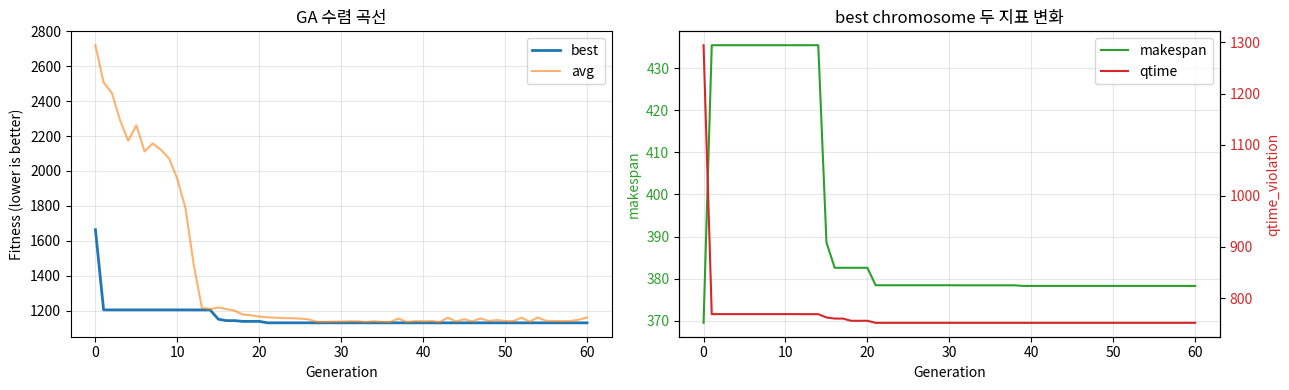

In [6]:
df_history = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) Fitness 수렴 곡선
axes[0].plot(df_history['gen'], df_history['best_fitness'], label='best', color='C0', linewidth=2)
axes[0].plot(df_history['gen'], df_history['avg_fitness'], label='avg', color='C1', alpha=0.6)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Fitness (lower is better)')
axes[0].set_title('GA 수렴 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) Best chromosome 두 지표 변화
ax2 = axes[1]
l1 = ax2.plot(df_history['gen'], df_history['best_makespan'], label='makespan', color='C2')
ax2.set_xlabel('Generation')
ax2.set_ylabel('makespan', color='C2')
ax2.tick_params(axis='y', labelcolor='C2')

ax2_t = ax2.twinx()
l2 = ax2_t.plot(df_history['gen'], df_history['best_qtime'], label='qtime', color='C3')
ax2_t.set_ylabel('qtime_violation', color='C3')
ax2_t.tick_params(axis='y', labelcolor='C3')

ax2.set_title('best chromosome 두 지표 변화')
ax2.grid(alpha=0.3)

lines = l1 + l2
ax2.legend(lines, [l.get_label() for l in lines], loc='upper right')

plt.tight_layout()
plt.show()

## 초기 vs 최종 비교

In [7]:
init = history[0]
final = history[-1]

print('─── 초기 (gen 0, 무작위) ───')
print(f"  best fitness: {init['best_fitness']:.2f}")
print(f"    makespan:   {init['best_makespan']:.2f}")
print(f"    qtime:      {init['best_qtime']:.2f}")
print(f"  avg  fitness: {init['avg_fitness']:.2f}")
print()
print('─── 최종 (GA 진화 후) ───')
print(f"  best fitness: {final['best_fitness']:.2f}")
print(f"    makespan:   {final['best_makespan']:.2f}")
print(f"    qtime:      {final['best_qtime']:.2f}")
print(f"  avg  fitness: {final['avg_fitness']:.2f}")
print()

def pct_change(initial, final_val):
    """초기값이 0이면 절대 변화량 표시, 아니면 변화율(%) 표시."""
    if initial == 0:
        return f'{initial:.2f} → {final_val:.2f} (초기값 0이라 변화율 미정의)'
    return f'{(final_val - initial) / initial * 100:+.1f}%'

print(f'best fitness 개선율: {pct_change(init["best_fitness"], final["best_fitness"])}')
print(f'makespan 변화율:     {pct_change(init["best_makespan"], final["best_makespan"])}')
print(f'qtime 변화율:        {pct_change(init["best_qtime"], final["best_qtime"])}')

─── 초기 (gen 0, 무작위) ───
  best fitness: 1663.95
    makespan:   369.51
    qtime:      1294.44
  avg  fitness: 2720.82

─── 최종 (GA 진화 후) ───
  best fitness: 1129.84
    makespan:   378.28
    qtime:      751.57
  avg  fitness: 1160.55

best fitness 개선율: -32.1%
makespan 변화율:     +2.4%
qtime 변화율:        -41.9%


## 최종 best chromosome 정보

In [11]:
sim_input_best = decode(best, encoded)

print('─── best chromosome fitness ───')
print(f'  makespan: {best.fitness[0]:.2f}')
print(f'  qtime:    {best.fitness[1]:.2f}')
print()
print('─── 디코딩 결과 (시뮬 실제 입력) ───')
print(f'  operation priority: {sim_input_best.operation_priority}')
print()
print(f'  op machine: {sim_input_best.op_machine}')
print()
print(f'  pm_thresholds: {sim_input_best.pm_thresholds}')
print()
print('  op별 머신 할당 (앞 10개):')
for op, m in list(sim_input_best.op_machine.items())[:10]:
    print(f'    {op} → {m}')

─── best chromosome fitness ───
  makespan: 378.28
  qtime:    751.57

─── 디코딩 결과 (시뮬 실제 입력) ───
  operation priority: {'J1_O1': 335, 'J1_O2': 784, 'J1_O3': 498, 'J1_O4': 701, 'J1_O5': 345, 'J1_O6': 309, 'J1_O7': 608, 'J1_O8': 184, 'J1_O9': 444, 'J1_O10': 40, 'J1_O11': 198, 'J1_O12': 359, 'J1_O13': 301, 'J1_O14': 507, 'J2_O1': 379, 'J2_O2': 774, 'J2_O3': 781, 'J2_O4': 723, 'J2_O5': 472, 'J2_O6': 348, 'J2_O7': 175, 'J2_O8': 494, 'J2_O9': 819, 'J2_O10': 217, 'J2_O11': 816, 'J2_O12': 259, 'J2_O13': 323, 'J2_O14': 219, 'J3_O1': 233, 'J3_O2': 783, 'J3_O3': 484, 'J3_O4': 28, 'J3_O5': 299, 'J3_O6': 532, 'J3_O7': 157, 'J3_O8': 395, 'J3_O9': 305, 'J3_O10': 485, 'J3_O11': 370, 'J3_O12': 254, 'J3_O13': 274, 'J3_O14': 513, 'J4_O1': 82, 'J4_O2': 5, 'J4_O3': 391, 'J4_O4': 582, 'J4_O5': 404, 'J4_O6': 544, 'J4_O7': 646, 'J4_O8': 502, 'J4_O9': 768, 'J4_O10': 746, 'J4_O11': 488, 'J4_O12': 20, 'J4_O13': 687, 'J4_O14': 634, 'J5_O1': 383, 'J5_O2': 728, 'J5_O3': 27, 'J5_O4': 684, 'J5_O5': 413, 'J5_O6': 188,

## Best chromosome 시뮬레이션 + 간트 차트

GA가 찾아낸 best chromosome으로 시뮬레이션을 한 번 더 돌려 간트 차트 시각화.

In [13]:
# best chromosome으로 시뮬레이션 재실행 (시드 고정 → fitness와 동일 결과)
random.seed(ga.evaluator.seed)

env = simpy.Environment()
event_logger = EventLogger(env)
scheduler = Scheduler(
    env=env,
    data=data,
    event_logger=event_logger,
    pm_hazard_threshold=0.0,
    opera_priority=sim_input_best.operation_priority,
    op_machine=sim_input_best.op_machine,
    pm_thresholds=sim_input_best.pm_thresholds,
)
env.run(until=scheduler.job_chk_process)

fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f'GA Best Chromosome 간트 차트 (Simulation Time: {round(env.now, 3)})'
)
fig.show()

TypeError: Scheduler.__init__() got an unexpected keyword argument 'job_priority'